# İş Akışı ve Hiperparametre Optimizasyonu

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

🏠 Ev fiyatları veri setini içe aktarın. Basitlik adına sadece sayısal özellikleri tutacağız

🎯 Hedefiniz en iyi KNN Regressor'ı yerleştirmek olacak. Özellikle, ev fiyatlarınız için en iyi tahminleri elde etmek üzere kaç tane "komşu" (<font color=blue>K</font>NN'deki <font color=blue>K</font>) göz önünde bulundurmalısınız?

In [7]:
# Load raw data
data = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/houses_train_raw.csv', index_col="Id")

# Only keep numerical columns and raws without NaN
data = data.select_dtypes(include=np.number).dropna()

data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


In [8]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

## 1. Eğitim/Test Ayrımı

❓ **Soru (Holdout)**❓

👇 `X_train`, `X_test`, `y_train` ve `y_test` oluşturmak için veri setini böl. Şunları kullan:
- `test_size=0.3`
- Sonuçlarınızı arkadaşınızla karşılaştırmak için `random_state=0`

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

## 2. Ölçeklendirme

⚖️ Ölçeklendirme KNN algoritması için her zaman kritik derecede önemlidir..

❓ **Soru (Ölçeklendirme)** ❓ 

* Eğitim setinizi ve test setinizi ölçeklendirin.
* Burada, basitçe `StandardScaler` uygulayalım ve özellik başına bir ölçekleyici seçerek zaman kaybetmeyelim. Gerçekten de, bu egzersizin amaçları şunlardır:
    * KNN'i gözden geçirmek
    * GridSearchCV'yi anlamak
    * RandomizedSearchCV'yi anlamak

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import pandas as pd

# 1. Eğitim setini dönüştür ve DataFrame yapısına sok
X_train_rescaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# 2. Test setini dönüştür ve DataFrame yapısına sok
X_test_rescaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## 3. Temel KNN modeli

❓ **Soru (KNN için bir temel)** ❓

Sadece _en yakın komşuyu_ dikkate alan basit bir KNN regressor'ı çapraz doğrulayın (*cv = 5*) ve 5 kat üzerindeki ortalama skoru hesaplayın.

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_validate

knn_model = KNeighborsRegressor()

cv_result = cross_validate(knn_model,X_train_rescaled,y_train,cv=5, scoring='r2')

cv_result["test_score"].mean()

0.7361762227737517

## 4. GridSearch

### 4.1. İlk GridSearch

❓ **Soru (GridSearch v1)**❓

En iyi KNN hiperparametresini `n_neighbors` bulmak için SKLearn `GridSearchCV` kullanalım.
- `n_neighbors` = [1,5,10,20,50] ile kaba taneli bir yaklaşım başlat
- Her parametreyi 5-kat çapraz doğrula
- `n_jobs` kullanarak performans sürenizi maksimize ettiğinizden emin olun

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# 1. Modeli Tanımla (Instantiate model)
knn_reg = KNeighborsRegressor()

# 2. Hiperparametre Izgarası (Hyperparameter Grid)
# Kaba taneli arama için belirtilen değerleri ekliyoruz
param_grid = {'n_neighbors': [1, 5, 10, 20, 50]}

# 3. Grid Search Tanımla (Instantiate Grid Search)
# cv=5: 5-kat çapraz doğrulama
# n_jobs=-1: Tüm işlemci çekirdeklerini kullan
grid_search = GridSearchCV(estimator=knn_reg,
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)

# 4. Veriyi Eğit (Fit data to Grid Search)
# Ölçeklendirilmiş eğitim verilerini kullanıyoruz
grid_search.fit(X_train_rescaled, y_train)

# En iyi parametreyi ve skoru görelim
print(f"En İyi n_neighbors: {grid_search.best_params_}")
print(f"En İyi R2 Skoru: {grid_search.best_score_}")


En İyi n_neighbors: {'n_neighbors': 10}
En İyi R2 Skoru: 0.7596697382171873


❓ **Soru (en iyi parametreler)** ❓

GridSearch'e göre, optimal K değeri nedir?

In [15]:
print(f"En İyi n_neighbors: {grid_search.best_params_}")

En İyi n_neighbors: {'n_neighbors': 10}


❓ **Soru (puanlama)** ❓ Optimal K değerinin ürettiği en iyi skor nedir?

In [16]:
print(f"En İyi R2 Skoru: {grid_search.best_score_}")

En İyi R2 Skoru: 0.7596697382171873


### 4.2. İkinci GridSearch

❓ **Soru (GridSearch V2)** ❓

Şimdi, en iyi $K$'nın nerede olduğu hakkında bir fikrimiz var, ancak denemediğimiz bazı değerler daha iyi bir performansla sonuçlanabilir.

* Önceki en iyi değerinizin çevresindeki $K$ için bazı değerleri deneyerek GridSearch'ü yeniden çalıştırın
* Bu rafine edilmiş GridSearch için `best_score` ve `best_k` nelerdir?

In [ ]:
# 1. Yeni ve Daha Hassas Hiperparametre Izgarası (Fine-grained Grid)
# Önceki en iyi sonucumuza göre (k=10) bu aralığı dinamik olarak belirleyebiliriz
# Örneğin: range(best_k - 4, best_k + 6)
refined_param_grid = {'n_neighbors': range(6, 16)}

# 2. Rafine Grid Search Tanımla
refined_grid_search = GridSearchCV(estimator=KNeighborsRegressor(),
                                   param_grid=refined_param_grid,
                                   cv=5,
                                   scoring='r2',
                                   n_jobs=-1)

# 3. Veriyi Yeniden Eğit
refined_grid_search.fit(X_train_rescaled, y_train)

# 4. Rafine Sonuçları Al
best_k = refined_grid_search.best_params_['n_neighbors']
best_score = refined_grid_search.best_score_

print(f"Rafine edilmiş en iyi k (best_k): {best_k}")
print(f"Rafine edilmiş en iyi R2 skoru (best_score): {best_score}")


Rafine edilmiş en iyi k (best_k): 15
Rafine edilmiş en iyi R2 skoru (best_score): 0.7657859104933367


***🧪 Kodunuzu test edin***

In [18]:
from nbresult import ChallengeResult
result = ChallengeResult('knn',
                         best_k=best_k,
                         best_score=best_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/D16D5-S-data-workflow/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_knn.py::TestKnn::test_best_k PASSED                                 [ 50%]
test_knn.py::TestKnn::test_best_score PASSED                             [100%]

============================== 2 passed in 0.19s ===============================


💯 You can commit your code:

git add tests/knn.pickle

git commit -m 'Completed knn step'

git push origin master



### 4.3. Görsel kontrol (manuel GridSearch)

☝️ Bu problem aslında manuel olarak GridSearch yapmak için yeterince basittir.

❓ **Soru(Manuel GridSearch)** ❓

- $K$'nın $1$'den $50$'ye kadar tüm değerleri üzerinde manuel olarak döngü yapın ve her modelin çapraz doğrulanmış skorlarının ortalamasını bir listede saklayın.
- `Dirsek Yöntemi` kullanarak en iyi $K$'yı görsel olarak bulmak için skorları $K$'nın bir fonksiyonu olarak çizin

In [ ]:
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

cv_results = []
k_range = range(1, 51)

for k in k_range:
    # Her döngüde farklı bir k değeri ile model kuruyoruz
    knn_model = KNeighborsRegressor(n_neighbors=k)

    # 5-kat çapraz doğrulama yapıyoruz
    cv_score = cross_validate(knn_model, X_train_rescaled, y_train, cv=5, scoring='r2')

    # Skorların ortalamasını listeye ekliyoruz
    cv_results.append(cv_score['test_score'].mean())

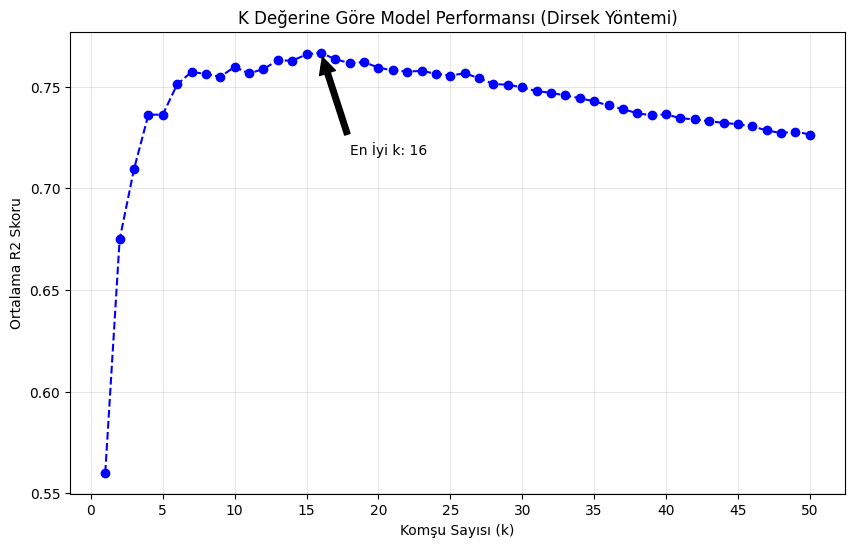

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_results, marker='o', linestyle='--', color='blue')

plt.title('K Değerine Göre Model Performansı (Dirsek Yöntemi)')
plt.xlabel('Komşu Sayısı (k)')
plt.ylabel('Ortalama R2 Skoru')
plt.xticks(range(0, 51, 5))
plt.grid(True, alpha=0.3)

# En iyi skoru işaretleyelim
best_k_idx = cv_results.index(max(cv_results))
plt.annotate(f'En İyi k: {k_range[best_k_idx]}',
             xy=(k_range[best_k_idx], cv_results[best_k_idx]),
             xytext=(k_range[best_k_idx]+2, cv_results[best_k_idx]-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

❓GridSearchCV'yi böyle bir manuel döngüden daha iyi bir seçenek yapan şeyi tahmin edebilir misiniz?

<details>
    <summary>Cevap</summary>

- Sklearn'ın `n_jobs=-1` seçeneği aramayı paralelleştirmenize izin verir, tüm CPU çekirdeklerinizi kullanır
- Birlikte optimize edilecek birden fazla hiperparametreniz olsaydı ne olurdu?
</details>

## 5. Birden çok parametre ile GridSearch

👩🏻‍🏫 KNNRegressor, `p` hiperparametresi aracılığıyla çeşitli _mesafe metrikleri_ destekler

📚 [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

❓ **Soru (birden çok parametreyi ayarlama)** ❓

* En iyi $K$ ve $p$'yi aynı anda aramak için GridSearchCV kullanın.
    * $K = [1, 5, 10, 20, 50]$ ve $p = [1, 2, 3]$ için tüm kombinasyonları deneyin.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# 1. Modeli Tanımla
knn_reg = KNeighborsRegressor()

# 2. Çoklu Parametre Izgarası (Hyperparameter Grid)
# Hem n_neighbors hem de p (mesafe metriği) kombinasyonlarını tanımlıyoruz
param_grid = {
    'n_neighbors': [1, 5, 10, 20, 50],
    'p': [1, 2, 3]
}

# 3. Grid Search Tanımla
# Tüm kombinasyonlar (5 x 3 = 15farklı model) 5-kat çapraz doğrulanacak
grid_search_multi = GridSearchCV(
    estimator=knn_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4. Veriyi Eğit
grid_search_multi.fit(X_train_rescaled, y_train)


En İyi Parametreler: {'n_neighbors': 10, 'p': 1}
En İyi R2 Skoru: 0.7969255879201194


❓ **Soru (alt model sayısı)**❓

Toplamda kaç alt model eğittiniz?

<details>
    <summary>İpucu</summary>

15'ten çok daha fazla. İki kez düşün :)
    <details>
    <summary>Cevap</summary>

CV=5 nedeniyle 75 model
</details>

In [22]:
import pandas as pd
results_df = pd.DataFrame(grid_search_multi.cv_results_)
print(results_df[['param_n_neighbors', 'param_p', 'mean_test_score']])

    param_n_neighbors  param_p  mean_test_score
0                   1        1         0.768976
1                   1        2         0.560154
2                   1        3         0.509235
3                   5        1         0.792764
4                   5        2         0.736176
5                   5        3         0.713155
6                  10        1         0.796926
7                  10        2         0.759670
8                  10        3         0.728985
9                  20        1         0.779081
10                 20        2         0.759292
11                 20        3         0.734643
12                 50        1         0.743216
13                 50        2         0.726424
14                 50        3         0.695056


❓ **Soru (modeli birden çok parametre ile ayarladıktan sonra en iyi parametreler ve en iyi skor)**❓

*En iyi parametreler* ve *en iyi skor* nedir?

In [23]:
# 5. En İyi Kombinasyonu Görüntüle
print(f"En İyi Parametreler: {grid_search_multi.best_params_}")
print(f"En İyi R2 Skoru: {grid_search_multi.best_score_}")

En İyi Parametreler: {'n_neighbors': 10, 'p': 1}
En İyi R2 Skoru: 0.7969255879201194


## 6. Rastgele Arama

Şimdi bir RandomizedSearch'ün aynı sayıda model yerleştirilerek daha iyi bir kombinasyon bulup bulamayacağını görelim.

❓ **Soru (RandomizedSearchCV)** ❓

`RandomizedSearchCV` kullanarak
- $K$'yı uniform `scipy.stats.randint(1,50)` ([döküman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html)) dağılımından rastgele örnekle
- $p$'yi $[1,2,3]$ listesinden örnekle
- Önceki GridSearchCV'nizdeki ile tam olarak aynı sayıda model yerleştirmek için doğru `n_iter` ve `cv` sayılarını kullanın.

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. Dağılımları Tanımla
# k için 1 ile 50 arasında (50 hariç) rastgele tam sayılar
param_distributions = {
    'n_neighbors': randint(1, 50),
    'p': [1, 2, 3]
}

# 2. RandomizedSearch Tanımla
# n_iter=10 ve cv=5 olduğu için toplamda 50 model eğitilecek
random_search = RandomizedSearchCV(
    estimator=KNeighborsRegressor(),
    param_distributions=param_distributions,
    n_iter=10,  # 10 farklı rastgele kombinasyon dene
    cv=5,       # Her birini 5-kat çapraz doğrula
    scoring='r2',
    n_jobs=-1,
    random_state=42 # Sonuçların tekrarlanabilir olması için
)

# 3. Veriyi Eğit
random_search.fit(X_train_rescaled, y_train)

# 4. Sonuçları Görüntüle
print(f"RandomizedSearch En İyi Parametreler: {random_search.best_params_}")
print(f"RandomizedSearch En İyi Skor: {random_search.best_score_}")

RandomizedSearch En İyi Parametreler: {'n_neighbors': 8, 'p': 1}
RandomizedSearch En İyi Skor: 0.7942356840941323


## 7. Genelleme

❓ **Soru (modelinizi bir kez daha ince ayarlama)**❓

- İsterseniz RandomsearchCV'nizi rafine edin
- En iyi modelinizi seçin

In [30]:
from sklearn.model_selection import GridSearchCV

best_k_from_random = random_search.best_params_['n_neighbors']
best_p_from_random = random_search.best_params_['p']

refined_param_grid = {
    'n_neighbors': list(range(max(1, best_k_from_random - 3), best_k_from_random + 4)),
    'p': [best_p_from_random]
}

# 2. Nihai Grid Search (Randomized yerine Grid kullanarak garantiye alıyoruz)
final_grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=refined_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

final_grid_search.fit(X_train_rescaled, y_train)

# Sonuçları kontrol edelim
print(f"Rafine edilmiş en iyi k: {final_grid_search.best_params_['n_neighbors']}")
print(f"Nihai R2 Skoru: {final_grid_search.best_score_:.4f}")

Rafine edilmiş en iyi k: 6
Nihai R2 Skoru: 0.7979


Şimdi `cv_results`'ınızı bir `DataFrame` olarak görüntülemeye çalışın, bu CV'nin içinde neler olup bittiğini görselleştirmenize yardımcı olacak! 😉

In [ ]:
import pandas as pd

# Sonuçları DataFrame'e çevirelim
results_df = pd.DataFrame(grid_search_multi.cv_results_)

# En önemli sütunları seçerek daha temiz bir görünüm elde edelim
display_columns = [
    'param_n_neighbors',
    'param_p',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

# Skora göre (en iyiden en kötüye) sıralayalım
sorted_results = results_df[display_columns].sort_values(by='rank_test_score')

print(sorted_results.head(10))

    param_n_neighbors  param_p  mean_test_score  std_test_score  \
6                  10        1         0.796926        0.045769   
3                   5        1         0.792764        0.059309   
9                  20        1         0.779081        0.035181   
0                   1        1         0.768976        0.077233   
7                  10        2         0.759670        0.048466   
10                 20        2         0.759292        0.043851   
12                 50        1         0.743216        0.033119   
4                   5        2         0.736176        0.079069   
11                 20        3         0.734643        0.040267   
8                  10        3         0.728985        0.049407   

    rank_test_score  
6                 1  
3                 2  
9                 3  
0                 4  
7                 5  
10                6  
12                7  
4                 8  
11                9  
8                10  


❓ **Soru ("En iyi" modelin değerlendirmesi)** ❓

* "En iyi parametrelerle" modelimizin **görülmemiş** test seti `X_test` üzerindeki performansını keşfetme zamanı geldi.
    * Test seti için r2 skorunu hesaplayın ve `r2_test` olarak kaydedin.

In [32]:
# 1. En iyi modeli (best_estimator_) kullanarak tahmin yapın ve skoru hesapla
# GridSearchCV/RandomizedSearchCV nesnesi içindeki en iyi modeli otomatik olarak kullanır
r2_test = final_grid_search.best_estimator_.score(X_test_rescaled, y_test)

# 2. Sonucu görüntüle
print(f"Test Seti R2 Skoru: {r2_test:.4f}")

# 3. Eğitim skoruyla kıyasla (Overfitting kontrolü için)
print(f"Eğitim (CV) R2 Skoru: {final_grid_search.best_score_:.4f}")

Test Seti R2 Skoru: 0.7849
Eğitim (CV) R2 Skoru: 0.7979


❓ **Soru (Bir adım geri çekilme)** ❓

Optimize edilmiş modelin iyi genelleme yaptığını düşünür müsünüz?

<details><summary>Cevap</summary>

Test skoru eğitim seti ile biraz azalabilir. Muhtemelen %5'ten fazla değil. Bunun nedeni şunlar olabilir:
- Temsili olmayan bir eğitim/test bölünmesi
- Model ayarlama aşamasında aşırı öğrenmeye yol açan çok küçük bir çapraz doğrulama sayısı. Ne kadar çok çapraz doğrulama yaparsanız, bulgularınız o kadar güçlü genelleşir - ancak veri setiniz çok küçükse cv'yi çok fazla artıramazsınız çünkü her katmanda temsili olmak için yeterli gözlemi tutamazsınız.
- Veri setimiz çok küçük ve hiperparametre optimizasyonumuz bu nedenle eğitim/test bölünmemize son derece bağımlı (ve aşırı uyum gösteriyor). Veri setinizin denediğiniz toplam hiperparametre kombinasyonu sayısından çok daha büyük olduğundan her zaman emin olun!
    
</details>

***🧪 Kodunuzu test edin***

In [ ]:
from nbresult import ChallengeResult
result = ChallengeResult('r2',
                         r2_test=r2_test)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/D16D5-S-data-workflow/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_r2.py::TestR2::test_r2 PASSED                                       [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/r2.pickle

git commit -m 'Completed r2 step'

git push origin master



🏁 Tebrikler! Artık GridSearchCV veya RandomizedSearchCV kullanarak bir modeli nasıl ince ayarlayacağınızı biliyorsunuz

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki meydan okumaya geçin!